# Part 2: K-Means Clustering — Finding Natural Segments
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — Customer Segmentation

Yesterday Sarah looked at the data in 2D. Today she finds the actual groups. She wants 3–6 customer segments — enough to be meaningful, few enough to actually act on with NorthStar's marketing team.

K-Means is the standard tool. Three big questions to answer:
1. **What K?** (How many clusters?)
2. **How well do they actually cluster?** (Silhouette score)
3. **What does each cluster MEAN?** (Profiling — naming each one)

**By the end of this notebook you will be able to:**
- Fit K-Means in one line
- Choose K with the elbow method + silhouette score
- Profile each cluster (what makes it distinctive)
- Name your clusters for a non-technical stakeholder

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — KMeans ready")

✅ Libraries loaded — KMeans ready


## Step 1 — Setup (same preprocessing as NB 02)

In [2]:
df = pd.read_csv("data/northstar_customers.csv")
features = df.drop(columns=["customer_id", "churned"])

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

X_processed = preprocessor.fit_transform(features)
print(f"Processed shape: {X_processed.shape}")

Processed shape: (10000, 17)


## Step 2 — How to pick K?

K-Means doesn't tell you K. You have to decide. Two standard heuristics:

### 1. Elbow method — Inertia (within-cluster sum of squares)

**Inertia** is the total squared distance from each customer to their assigned cluster centre.

> For every customer: compute the distance to their cluster's centre → square it → sum all of these up.

Lower inertia = tighter clusters. But there's a catch: adding more clusters *always* reduces inertia — at the extreme, K = N gives inertia of zero (each customer is their own cluster of one). So we don't minimise inertia; we look for the **elbow** — the K where adding one more cluster gives diminishing returns on tightness.

### 2. Silhouette score — how well does each customer fit their cluster?

For each customer, the silhouette score compares two things:
- **a** = mean distance to all other customers *in the same cluster* (cohesion — how tight is this cluster?)
- **b** = mean distance to all customers *in the nearest other cluster* (separation — how far from the next-best option?)

$$\text{silhouette} = \frac{b - a}{\max(a, b)}$$

- Score near **+1** → customer is much closer to their own cluster than any other (well-placed)
- Score near **0** → customer sits on the boundary between two clusters (ambiguous)
- Score near **−1** → customer would fit better in a neighbouring cluster (misassigned)

The overall silhouette score is the **mean across all customers**. Higher is better — and unlike inertia, it doesn't always improve with more K. It peaks at the K that best balances cohesion and separation.

We'll compute both for K = 2, 3, ..., 10.

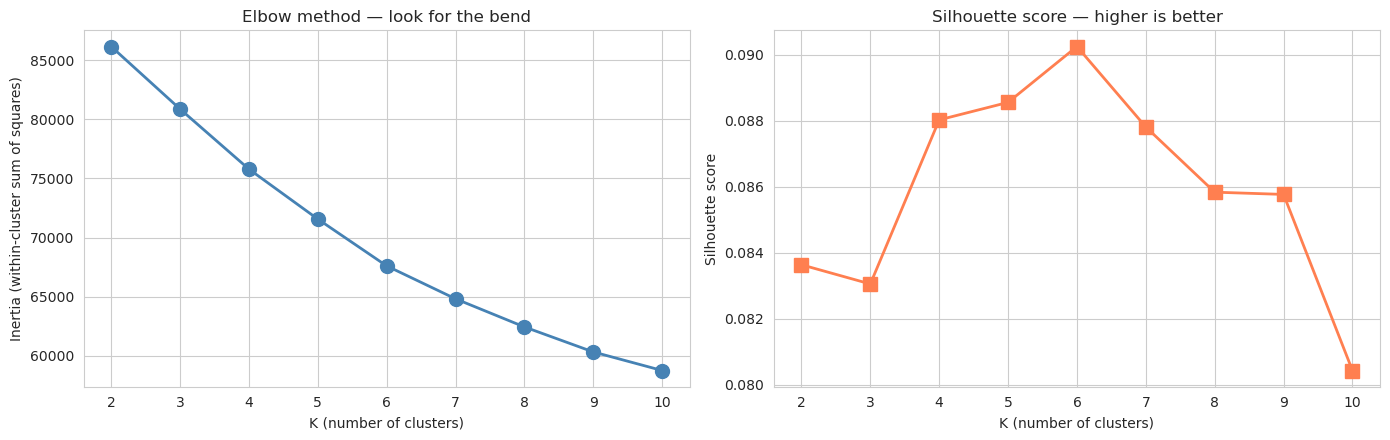

K     Inertia    Silhouette
  2        86155     0.0836
  3        80868     0.0830
  4        75787     0.0880
  5        71564     0.0886
  6        67604     0.0902
  7        64821     0.0878
  8        62444     0.0858
  9        60330     0.0858
  10        58760     0.0804


In [3]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(K_range, inertias, "o-", linewidth=2, color="steelblue", markersize=10)
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method — look for the bend")

axes[1].plot(K_range, silhouettes, "s-", linewidth=2, color="coral", markersize=10)
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score — higher is better")

plt.tight_layout()
plt.show()

print("K     Inertia    Silhouette")
for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"  {k}   {inertia:10.0f}     {sil:.4f}")

## ⏸️ Pause and Predict

Look at the elbow plot and silhouette plot. Before reading on, decide:
- What K would you pick?
- What would you tell Marcus if he asked WHY?

*Your prediction:*

> *Hints to consider:*
> - The elbow plot's "bend" is rarely sharp on real data. Often it's a smooth curve — look for where the slope starts to flatten.
> - Silhouette score peaks at SOME K — check the printed table to find which K scores highest. That's the statistical vote.
> - **Business judgement matters.** The silhouette-optimal K is not always the most *actionable* K. A very high K (e.g. 8–10) segments customers finely but multiplies operational complexity — six different email tracks, six sets of offers. A very low K (e.g. 2) is easy to brief but too coarse to be useful. Sweet spot for most business contexts: **3–5 segments**.

## Step 3 — Pick K = 4

We'll commit to **K = 4**.

From the printed table, silhouette peaks at **K = 6** (score 0.0902). So why not K = 6?

| Consideration | K = 6 | K = 4 |
|---|---|---|
| **Silhouette score** | 0.0902 ✓ (best) | 0.0880 (close) |
| **Statistical signal** | Marginally tighter clusters | Nearly identical quality |
| **Operational cost** | 6 email tracks, 6 offer sets, 6 slide rows | 4 — manageable for one marketing team |
| **Presentation clarity** | Hard to name 6 distinct segments crisply | 4 clear names fit on a slide |

The score difference between K=4 and K=6 is 0.002 — essentially noise at this dataset size. The business cost of 6 segments over 4 is real. **We pick K = 4.**

> **The general rule:** optimise for the smallest K that still gives meaningfully different segments, and that a non-technical stakeholder can act on. Here, K = 4 meets that bar.

In [4]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X_processed)

# Add cluster labels to the original dataframe (with raw features)
df_clustered = features.copy()
df_clustered["cluster"] = labels

# Cluster sizes
print(f"K = {K}")
print()
print("Cluster sizes:")
print(df_clustered["cluster"].value_counts().sort_index().to_string())

K = 4

Cluster sizes:
cluster
0    3463
1    1138
2    3540
3    1859


### 🔗 How does K = 4 relate to the PC1/PC2 plot coming up?

These are **two separate steps doing two different jobs** — it's worth being clear before you read the plot:

- **K = 4 is the *grouping* decision.** K-Means just assigned every customer a label (0–3) using **all 17 dimensions**. That "4" came from the elbow + silhouette analysis plus business judgement — PCA had nothing to do with it.
- **PC1/PC2 is just the *picture*.** In the next step PCA squashes those 17 dimensions down to 2 so we can draw the result on a flat screen. PCA does **not** re-cluster anything and does not know K = 4 exists.

The upcoming scatter plot stacks these two layers on one chart:

| Layer | Comes from | What it controls |
|---|---|---|
| **Where each dot sits** (its PC1, PC2 coordinates) | PCA | position on the map |
| **What colour each dot is** (0–3) | K-Means (Step 3) | which segment it belongs to |

So: **PCA places the dots, K-Means colours them.** You'll see roughly 4 coloured regions *because we chose 4 groups and 4 colours* — not because PC1/PC2 naturally split the data into 4. If we'd picked K = 6, the exact same axes would just show 6 colours.

One caveat to keep in mind: PC1 + PC2 capture only ~22% of the total spread, so groups K-Means separated cleanly in 17-D can look squished together on this 2-D map. That overlap is mostly an artefact of flattening — which is why Extension 4 adds a 3-D view to recover more of the separation.

## Step 4 — Visualise clusters in PCA space

Project to 2D with PCA (from NB 02) and colour by cluster. This is the picture Sarah will put on the Friday slides.

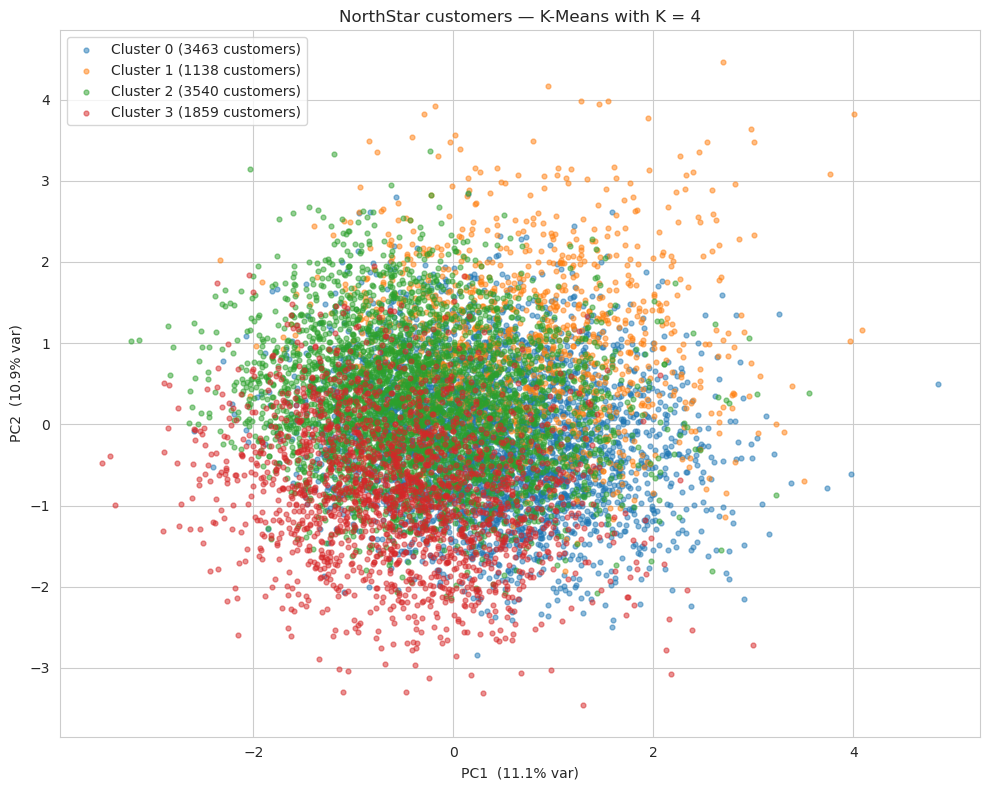

In [5]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_processed)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]
for c in range(K):
    mask = labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                alpha=0.5, s=12, color=colors[c],
                label=f"Cluster {c} ({mask.sum()} customers)")
ax.set_xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"NorthStar customers — K-Means with K = {K}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 💡 What you should notice

- The clusters are **visible in PCA space**, even though the 2D coloured cloud wasn't obviously separable in NB 02.
- K-Means is using ALL 17 dimensions to find the groups — the 2D plot is just a projection of that result.
- Some overlap is normal. K-Means assigns every customer to exactly ONE cluster (hard assignment) — there are no "in-between" customers.

## Step 5 — Cluster profiles: what makes each cluster distinctive?

For each cluster, compute the mean of every feature. Compare to the global mean to spot what each cluster is about.

In [6]:
# Profile each cluster on the ORIGINAL (unscaled) numeric features
numeric_cols = ["age", "tenure_months", "num_purchases_quarter",
                "avg_monthly_spend_gbp", "returns_per_purchase",
                "last_login_days_ago", "avg_review_polarity",
                "support_tickets_quarter"]

profile = df_clustered.groupby("cluster")[numeric_cols].mean().round(2)
global_mean = features[numeric_cols].mean().round(2)
profile.loc["GLOBAL_MEAN"] = global_mean

print("Cluster profiles vs global mean:")
print(profile.to_string())

Cluster profiles vs global mean:
               age  tenure_months  num_purchases_quarter  avg_monthly_spend_gbp  returns_per_purchase  last_login_days_ago  avg_review_polarity  support_tickets_quarter
cluster                                                                                                                                                                 
0            48.97          54.90                   6.05                  71.07                  0.09                21.33                 0.16                     1.25
1            49.69          36.48                   6.10                  70.55                  0.13                91.90                 0.12                     1.17
2            48.48          16.52                   6.00                  68.82                  0.10                20.92                 0.13                     1.15
3            48.41          36.25                   5.98                  68.62                  0.31                22.01

## Step 6 — Heatmap of standardised differences

A heatmap makes the "what's different" pattern visible at a glance. Standardise each cluster's mean by subtracting the global mean and dividing by the global standard deviation.

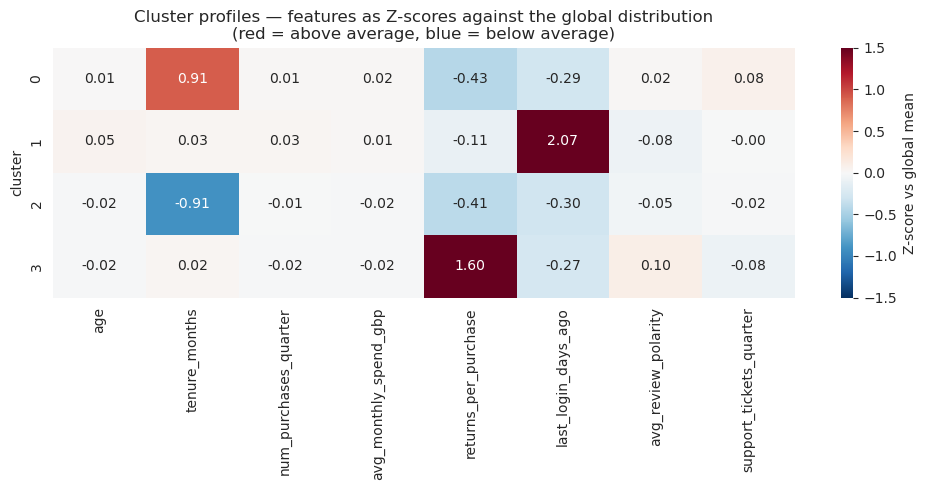

In [7]:
# Z-score each cluster's mean against the global distribution
global_std  = features[numeric_cols].std()
cluster_means = df_clustered.groupby("cluster")[numeric_cols].mean()
z_scores = (cluster_means - global_mean) / global_std

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(z_scores, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, cbar_kws={"label": "Z-score vs global mean"}, ax=ax)
ax.set_title(f"Cluster profiles — features as Z-scores against the global distribution\n(red = above average, blue = below average)")
plt.tight_layout()
plt.show()

### 💡 What this tells us — naming the clusters

Each row of the heatmap has one or two dominant colours. That's the signal. Everything else is noise.

| Cluster | Size | Dominant signals | Name |
|---|---|---|---|
| **0** | 3,463 (35%) | `tenure_months` +0.91 ↑, `returns` −0.43 ↓, `last_login` −0.29 ↓ | **"Loyal Veterans"** |
| **1** | 1,138 (11%) | `last_login_days_ago` +2.07 ↑↑ (everything else average) | **"Dormant / At-Risk"** |
| **2** | 3,540 (35%) | `tenure_months` −0.91 ↓, `returns` −0.41 ↓, `last_login` −0.30 ↓ | **"New Actives"** |
| **3** | 1,859 (19%) | `returns_per_purchase` +1.60 ↑↑ (everything else average) | **"Serial Returners"** |

**Reading each cluster:**

- **Cluster 0 — "Loyal Veterans"** (35% of base): Long-tenured, few returns, recently logged in. The healthiest segment. Prime candidates for loyalty rewards or a premium upsell campaign.

- **Cluster 1 — "Dormant / At-Risk"** (11% of base): Average on almost every feature — but they haven't logged in for a very long time (last login +2.07 SD above the mean). They look fine on paper; they're silently churning. Top priority for a re-engagement campaign.

- **Cluster 2 — "New Actives"** (35% of base): New customers (short tenure) who are nonetheless recently active and returning little. They're engaged and finding what they want. Onboarding, early loyalty incentives, and cross-sell are the right plays.

- **Cluster 3 — "Serial Returners"** (19% of base): Return rate is the single defining feature — dramatically above average (+1.60 SD). Everything else is unremarkable. This could be size/fit issues, expectation mismatches, or opportunistic buy-return behaviour. Worth a product team conversation before running any promotions on this group.

**Key insight:** The clearest signals in this dataset are *tenure*, *login recency*, and *return rate* — not spend or age. That's what the data is telling Sarah and Marcus to act on.

## ✅ Section Summary

| What we did | Output |
|---|---|
| **Computed elbow + silhouette** for K = 2-10 | Two metrics for choosing K |
| **Picked K = 4** | Business judgement — actionable number of segments |
| **Fit K-Means** | 4 cluster labels, one per customer |
| **Plotted in PCA space** | Visible groupings even when raw 2D wasn't obvious |
| **Profiled each cluster** | Per-cluster feature means + heatmap of Z-score differences |
| **Named the segments** | The output Marcus actually wants — meaningful labels, not numbers |

**Key insight for our scenario:**
> K-Means alone gives Sarah numbers (cluster 0, 1, 2, 3). The VALUE comes from profiling — translating "cluster 2" into "Loyal high-value customers, 26% of base, candidates for the premium upsell campaign."

---
**Up next → Part 3:** Thursday — Isolation Forest for anomaly detection. Find unusual customers worth investigating.
Open `04_isolation_forest.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Reproducibility: K-Means and random_state

K-Means starts from random initial centroids. With `n_init=10` (default), it tries 10 different starting points and keeps the best. But two runs with different `random_state` can still give slightly different cluster ASSIGNMENTS — even if the clusters themselves are very similar.

ALWAYS set `random_state` for reproducible work.

In [8]:
# Compare K-Means with two different random_states
km_42  = KMeans(n_clusters=4, random_state=42, n_init=10)
km_123 = KMeans(n_clusters=4, random_state=123, n_init=10)

labels_42  = km_42.fit_predict(X_processed)
labels_123 = km_123.fit_predict(X_processed)

# Cluster sizes
sizes_42  = pd.Series(labels_42).value_counts().sort_index().values
sizes_123 = pd.Series(labels_123).value_counts().sort_index().values

print(f"Cluster sizes with random_state=42:   {sizes_42}")
print(f"Cluster sizes with random_state=123:  {sizes_123}")

# Pairwise agreement — what fraction of customers got the SAME cluster?
# (Note: cluster IDs might be permuted between the two runs. Best to use ARI.)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_42, labels_123)
print()
print(f"Adjusted Rand Index between the two runs: {ari:.3f}")
print("→ ARI ≈ 1 means same clustering. ARI ≈ 0 means random agreement.")
print("→ K-Means is usually stable on tabular data; random_state matters mostly for getting EXACT reproducibility.")

Cluster sizes with random_state=42:   [3463 1138 3540 1859]
Cluster sizes with random_state=123:  [3908  856 1218 4018]

Adjusted Rand Index between the two runs: 0.569
→ ARI ≈ 1 means same clustering. ARI ≈ 0 means random agreement.
→ K-Means is usually stable on tabular data; random_state matters mostly for getting EXACT reproducibility.


## Extension 2 — When K-Means struggles: non-globular clusters

K-Means assumes clusters are SPHERICAL (roughly equal in all directions). When the natural clusters are elongated, stringy, or irregularly shaped, K-Means fails — it carves up the natural shapes into pieces.

For non-globular structure, use **DBSCAN** (density-based) — covered in `optional_extensions.ipynb`.

For now, here's a synthetic demo to make the limitation visible.

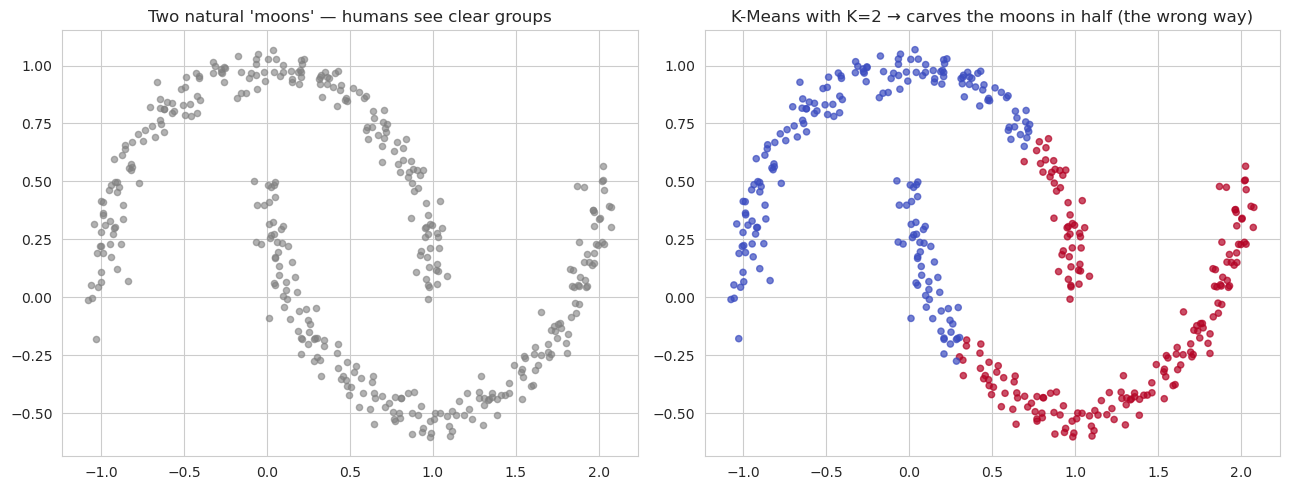

→ K-Means fails on non-globular shapes. Use DBSCAN if you suspect this.


In [9]:
from sklearn.datasets import make_moons

# Two interlocking moons — clearly two groups, but not spherical
X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

km_demo = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_demo = km_demo.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], s=20, color="gray", alpha=0.6)
axes[0].set_title("Two natural 'moons' — humans see clear groups")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_demo, cmap="coolwarm", s=20, alpha=0.7)
axes[1].set_title("K-Means with K=2 → carves the moons in half (the wrong way)")

plt.tight_layout()
plt.show()
print("→ K-Means fails on non-globular shapes. Use DBSCAN if you suspect this.")

## Extension 3 — Mini-batch K-Means for large datasets

For very large datasets (>100k rows), regular K-Means is slow. `MiniBatchKMeans` uses random subsets each iteration — much faster, almost as accurate.

In [10]:
from sklearn.cluster import MiniBatchKMeans
import time

# Time regular vs mini-batch
start = time.time()
km_full = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_processed)
t_full = time.time() - start

start = time.time()
km_mini = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=512, n_init=10).fit(X_processed)
t_mini = time.time() - start

# Compare cluster qualities
sil_full = silhouette_score(X_processed, km_full.labels_)
sil_mini = silhouette_score(X_processed, km_mini.labels_)

print(f"Full KMeans:    time = {t_full*1000:.0f}ms, silhouette = {sil_full:.4f}")
print(f"MiniBatch:      time = {t_mini*1000:.0f}ms, silhouette = {sil_mini:.4f}")
print()
print("MiniBatchKMeans is the right choice when full KMeans takes >10s.")
print("For our 10k-row dataset, the difference is small. For 1M+ rows it's enormous.")

Full KMeans:    time = 3058ms, silhouette = 0.0880
MiniBatch:      time = 922ms, silhouette = 0.0771

MiniBatchKMeans is the right choice when full KMeans takes >10s.
For our 10k-row dataset, the difference is small. For 1M+ rows it's enormous.


## Extension 4 — Seeing the clusters more clearly

In **Step 4** all four clusters were drawn on top of each other in one 2D PCA scatter, and they overlap heavily. That overlap is partly real and partly an artefact of the picture:

- **It's partly real.** The silhouette score here is only ~0.09 — these are *soft* segments defined by a few features (tenure, login recency, return rate), not sharply separated blobs. No plot can make genuinely-overlapping data look cleanly split, and pretending otherwise would be dishonest.
- **It's partly the plot.** PC1 + PC2 capture only a slice of the 17-dimensional variance, and 10,000 semi-transparent dots piled in one axes hide every centre. We can fix *this* part with better plotting choices.

Three techniques that make the structure far easier to read — **none of them change the clustering, only how we look at it**:

1. **Small multiples (facets)** — one panel per cluster. Each panel greys out everyone else and highlights one cluster plus its **centroid (★)**. Overplotting disappears, and you can see where each group actually sits.
2. **A 3D PCA view** — add PC3 as a third axis. Groups that sit on top of each other in 2D often pull apart along the extra dimension.
3. **Centroid markers** — even on the combined plot, drawing the four centres as large stars makes "where is each cluster's centre of gravity" obvious, which was the original complaint.

> 💡 **Takeaway for slides:** for a non-technical audience, the *faceted* view and the *named heatmap* from Step 6 communicate the segments far better than a single overlapping scatter. The scatter shows "the model found structure"; the facets + heatmap show "here is what each group is."

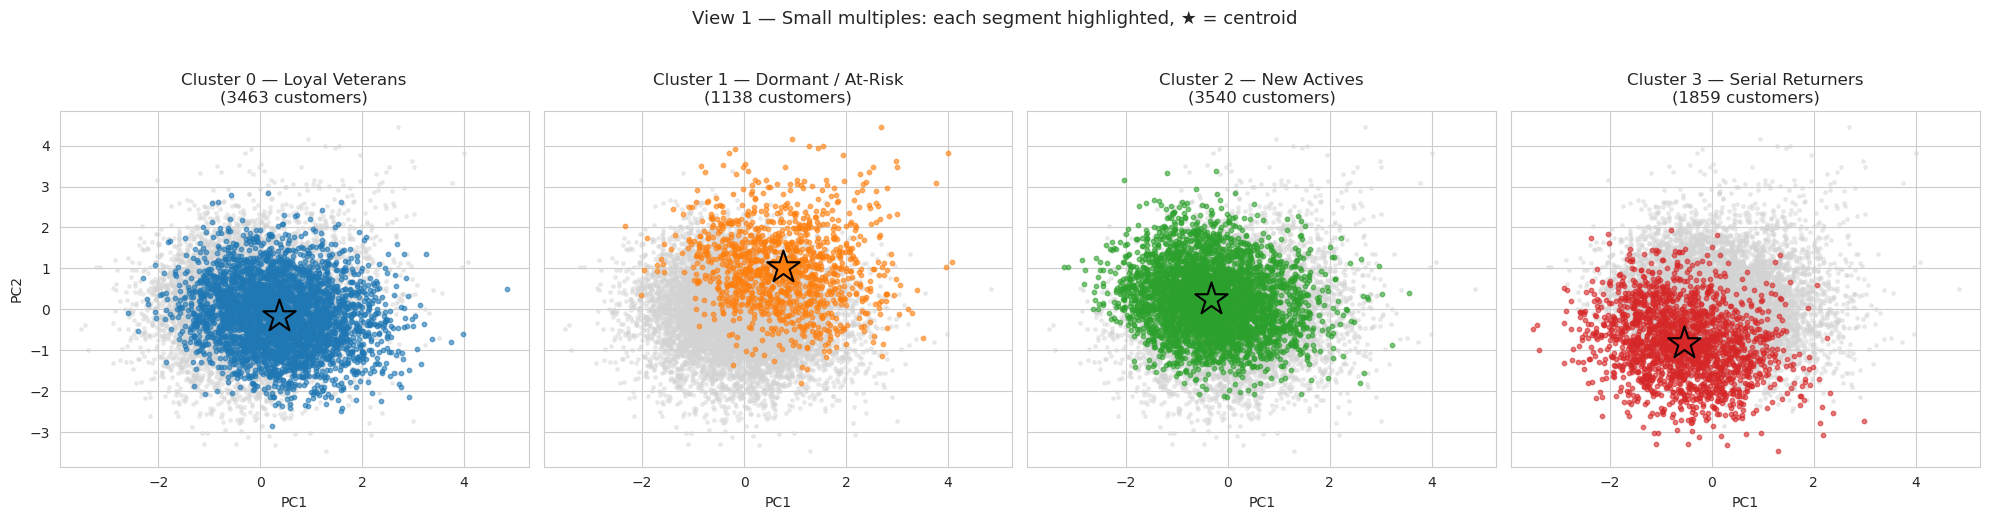

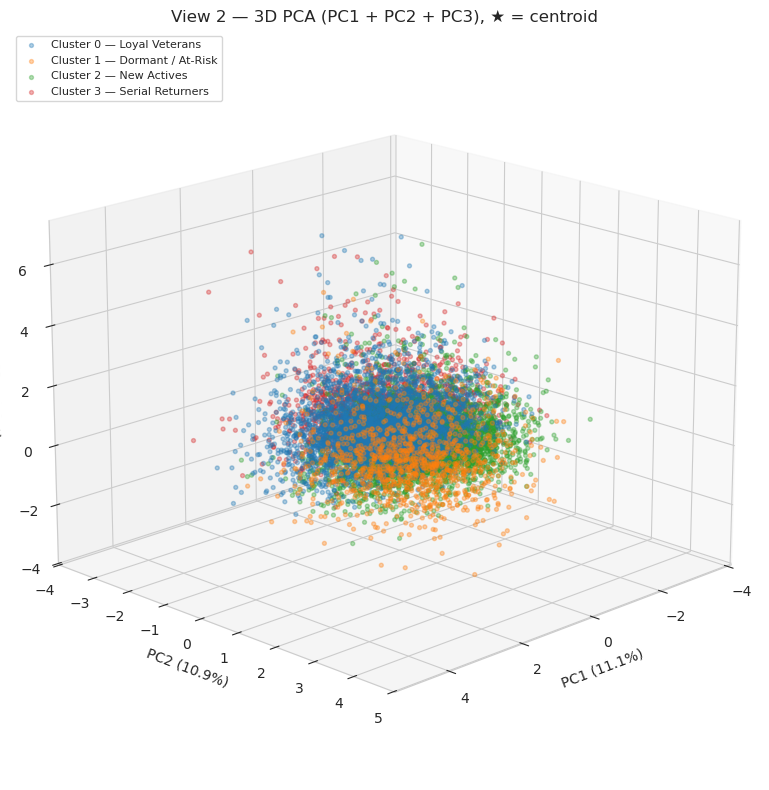

PC1-PC3 together capture 32.8% of total variance (vs 22.0% for PC1-PC2 alone).
→ In a Jupyter window, run `%matplotlib widget` (or `notebook`) before this cell
  to drag-rotate the 3D plot live. Static export uses the view_init angle above.


In [11]:
# Extension 4 — clearer views of the SAME K=4 clustering (no re-fitting)
# Reuses `km`, `labels`, `X_processed`, `pca_2d`, `X_2d`, `colors`, `K` from Steps 3-4.

cluster_names = ["Loyal Veterans", "Dormant / At-Risk", "New Actives", "Serial Returners"]

# Project the cluster centroids into the same 2D PCA space as the customers
centroids_2d = pca_2d.transform(km.cluster_centers_)

# ----------------------------------------------------------------------
# VIEW 1 — Small multiples: one panel per cluster (kills overplotting)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, K, figsize=(5 * K, 5), sharex=True, sharey=True)
for c in range(K):
    ax = axes[c]
    # Everyone else, in light grey for context
    other = labels != c
    ax.scatter(X_2d[other, 0], X_2d[other, 1], s=6, color="lightgrey", alpha=0.4)
    # This cluster, highlighted
    mask = labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=10, color=colors[c], alpha=0.6)
    # Its centroid as a big star
    ax.scatter(centroids_2d[c, 0], centroids_2d[c, 1],
               marker="*", s=600, color=colors[c], edgecolor="black", linewidth=1.5, zorder=5)
    ax.set_title(f"Cluster {c} — {cluster_names[c]}\n({mask.sum()} customers)")
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.suptitle("View 1 — Small multiples: each segment highlighted, ★ = centroid", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# VIEW 2 — 3D PCA: add PC3 so groups that overlap in 2D can pull apart
# ----------------------------------------------------------------------
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_processed)
centroids_3d = pca_3d.transform(km.cluster_centers_)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for c in range(K):
    mask = labels == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               s=8, color=colors[c], alpha=0.35, label=f"Cluster {c} — {cluster_names[c]}")
    ax.scatter(centroids_3d[c, 0], centroids_3d[c, 1], centroids_3d[c, 2],
               marker="*", s=500, color=colors[c], edgecolor="black", linewidth=1.5)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")
ax.set_title("View 2 — 3D PCA (PC1 + PC2 + PC3), ★ = centroid")
ax.legend(loc="upper left", fontsize=8)
ax.view_init(elev=18, azim=45)   # rotate this angle to explore the structure
plt.tight_layout()
plt.show()

cum_var = pca_3d.explained_variance_ratio_.sum()
print(f"PC1-PC3 together capture {cum_var:.1%} of total variance "
      f"(vs {pca_2d.explained_variance_ratio_.sum():.1%} for PC1-PC2 alone).")
print("→ In a Jupyter window, run `%matplotlib widget` (or `notebook`) before this cell")
print("  to drag-rotate the 3D plot live. Static export uses the view_init angle above.")


### Interactive 3D — pick any PCs for each axis and rotate

The Matplotlib 3D plot above is static. With **Plotly** we get a fully interactive version: **drag to rotate**, scroll to zoom, hover for a customer's details, and click legend entries to show/hide clusters.

It also adds three **dropdown menus** (one per axis) so you can put *any* principal component on X, Y, or Z — not just PC1/PC2/PC3. PCA orders components by variance explained, so PC1–PC3 are the default. But two clusters that overlap on the big components sometimes separate cleanly on a *later* one (e.g. PC4 might isolate the "Serial Returners"). The dropdowns let you hunt for the angle that best splits a particular pair.

The cell renders inline **and** writes a standalone `03_kmeans_interactive_3d.html` you can open in any browser or drop into the Friday slides — no Python needed to view it.

In [12]:
!pip install plotly

import plotly.graph_objects as go

# ---- Project customers + centroids onto the first N_PC principal components ----
N_PC = 6                                   # how many PCs to make selectable
pca_nd = PCA(n_components=N_PC)
X_nd = pca_nd.fit_transform(X_processed)
centroids_nd = pca_nd.transform(km.cluster_centers_)
pc_var = pca_nd.explained_variance_ratio_
pc_labels = [f"PC{i+1} ({pc_var[i]:.1%})" for i in range(N_PC)]

# Subsample the 10k points so the HTML stays light and rotation stays smooth
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_nd), size=min(3000, len(X_nd)), replace=False)
Xs, labs = X_nd[sample_idx], labels[sample_idx]

DEFAULT = (0, 1, 2)                          # PC1, PC2, PC3
cluster_names = ["Loyal Veterans", "Dormant / At-Risk", "New Actives", "Serial Returners"]
colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]

# ---- Build traces: one per cluster + one for the centroids ----
fig = go.Figure()
for c in range(K):
    m = labs == c
    fig.add_trace(go.Scatter3d(
        x=Xs[m, DEFAULT[0]], y=Xs[m, DEFAULT[1]], z=Xs[m, DEFAULT[2]],
        mode="markers", name=f"Cluster {c} — {cluster_names[c]}",
        marker=dict(size=3, color=colors[c], opacity=0.55),
        hovertemplate=f"Cluster {c} — {cluster_names[c]}<extra></extra>"))
# Centroids as big black-outlined diamonds
fig.add_trace(go.Scatter3d(
    x=centroids_nd[:, DEFAULT[0]], y=centroids_nd[:, DEFAULT[1]], z=centroids_nd[:, DEFAULT[2]],
    mode="markers", name="Centroids",
    marker=dict(size=9, color=colors, symbol="diamond",
                line=dict(color="black", width=2)),
    hovertext=[f"Centroid {c}" for c in range(K)], hoverinfo="text"))

# x-data for every trace when a given PC is chosen for an axis
def axis_data(pc):
    return [Xs[labs == c, pc] for c in range(K)] + [centroids_nd[:, pc]]

# ---- Three dropdowns (X, Y, Z), each restyles all traces to the chosen PC ----
def menu(axis_key, default_pc, x_anchor):
    return dict(
        buttons=[dict(label=f"{axis_key.upper()} = PC{i+1}",
                      method="restyle",
                      args=[{axis_key: axis_data(i)}]) for i in range(N_PC)],
        active=default_pc, x=x_anchor, y=1.12, xanchor="left",
        showactive=True, direction="down")

fig.update_layout(
    title="Interactive 3D PCA — drag to rotate · use dropdowns to change each axis",
    updatemenus=[menu("x", DEFAULT[0], 0.00),
                 menu("y", DEFAULT[1], 0.22),
                 menu("z", DEFAULT[2], 0.44)],
    scene=dict(xaxis_title="X axis (PC)", yaxis_title="Y axis (PC)", zaxis_title="Z axis (PC)"),
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.99),
    margin=dict(l=0, r=0, t=90, b=0), height=700)

# Save a standalone HTML (works offline) and show inline
out_html = "03_kmeans_interactive_3d.html"
fig.write_html(out_html, include_plotlyjs="cdn")
print(f"✅ Saved interactive plot → {out_html}")
print(f"   PCs available on each axis: {', '.join(pc_labels)}")
print("   Tip: the dropdowns swap which PC sits on X / Y / Z; drag the plot to rotate.")
fig.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.8 MB/s  0:00:00
✅ Saved interactive plot → 03_kmeans_interactive_3d.html
   PCs available on each axis: PC1 (11.1%), PC2 (10.9%), PC3 (10.9%), PC4 (10.7%), PC5 (10.7%), PC6 (10.5%)
   Tip: the dropdowns swap which PC sits on X / Y / Z; drag the plot to rotate.


### How do you decide *which* PC to put on the third axis?

A 2D plot uses PC1 and PC2. For 3D you need a third axis — so which PC do you add? There are two different criteria, and learners should understand why they can disagree.

**Criterion 1 — variance explained (the naive default).**
PCA numbers the components by how much *total* variance each captures, biggest first. So the obvious choice is **PC3** — the most "important" remaining direction. This is the right default when the first few PCs dominate (e.g. PC1 = 40%, PC2 = 25%, PC3 = 15%). Adding PC3 then shows you most of what 2D was missing.

**Criterion 2 — cluster separation (what we actually care about here).**
Variance is about the spread of *all* customers, not about pulling our *clusters* apart. A component can hold lots of variance yet have every cluster sitting on top of each other along it — useless for this plot. What we want for the third axis is the PC where the **cluster centroids are most spread out**: the direction that best separates the groups.

These two criteria coincide when the high-variance PCs are also the ones that define the clusters — but they don't have to. **In this dataset the variances are almost flat (~11% each), so "PC3 because it's third" carries no real weight.** The honest move is to *measure* which PC best separates the clusters and put that one on the third axis.

**How to measure separation per PC.** Treat each PC as a single feature and ask "how well does it tell the clusters apart?" The standard score is the **one-way ANOVA F-statistic** (`f_classif`): high F = the cluster means are far apart relative to the within-cluster scatter along that PC. Rank the PCs by F, keep PC1/PC2 for familiarity, then pick the **highest-F component beyond them** for the third axis. (The interactive dropdowns above let you then eyeball-confirm the choice.)

The next cell does exactly this — and the result is a great cautionary tale: on this dataset the naive "just add PC3" choice turns out to be one of the **worst** separators, while a *low*-variance component separates the clusters best. Variance rank and separation rank can be almost opposite.

In [13]:
# Which PC best separates the clusters? Rank PCs two ways: variance vs separation.
from sklearn.feature_selection import f_classif

# Use the N_PC-dimensional projection + km labels from the cells above
f_stat, _ = f_classif(X_nd, labels)          # ANOVA F per PC: high = separates clusters well

ranking = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(N_PC)],
    "variance_explained": pca_nd.explained_variance_ratio_,
    "separation_F": f_stat,
}).sort_values("separation_F", ascending=False).reset_index(drop=True)

print("PCs ranked by how well they SEPARATE the 4 clusters (ANOVA F-statistic):\n")
print(ranking.to_string(index=False,
      formatters={"variance_explained": "{:.1%}".format, "separation_F": "{:,.0f}".format}))

# Recommend a third axis: best separator that isn't already PC1/PC2
best_third = next(pc for pc in ranking["PC"] if pc not in ("PC1", "PC2"))
print(f"\n→ For the 3D plot, keep PC1 + PC2, and add **{best_third}** as the third axis")
print("   (it separates the clusters best among the remaining components).")
print("   Note how separation rank ≠ variance rank — variance alone would NOT pick this one.")


PCs ranked by how well they SEPARATE the 4 clusters (ANOVA F-statistic):

 PC variance_explained separation_F
PC6              10.5%        2,133
PC5              10.7%        1,823
PC4              10.7%        1,384
PC2              10.9%        1,258
PC1              11.1%          824
PC3              10.9%          260

→ For the 3D plot, keep PC1 + PC2, and add **PC6** as the third axis
   (it separates the clusters best among the remaining components).
   Note how separation rank ≠ variance rank — variance alone would NOT pick this one.
